# Branching mechanisms and selectivity

Many catalytic reactions share a **common intermediate** that can react along more than one pathway. Which product you get — the *selectivity* — is then a competition between branches, not a single rate. This example builds a minimal selective-oxidation mechanism, computes the selectivity, shows the classic **activity/selectivity tradeoff**, and asks the AD question: *which steps should I change to improve selectivity?* (the **degree of selectivity control**).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
%matplotlib inline

## A branching mechanism

A reactant `A` and oxygen co-adsorb and couple into a common surface oxygenate `AO*`, which then **branches**:

$$\begin{aligned}
A + * &\rightleftharpoons A^* \\
O_2 + 2* &\rightleftharpoons 2\,O^* \\
A^* + O^* &\rightleftharpoons AO^* + * &&\text{(form the common intermediate)}\\
AO^* &\rightleftharpoons P_1 + * &&\text{(selective: } AO^* \to P_1)\\
AO^* + O^* &\rightleftharpoons P_2 + 2* &&\text{(over-oxidation: } AO^* \to P_2)
\end{aligned}$$

`P1` is the desired partial-oxidation product; `P2` is over-oxidized. The branch ratio is governed by the oxygen coverage $\theta_O$.

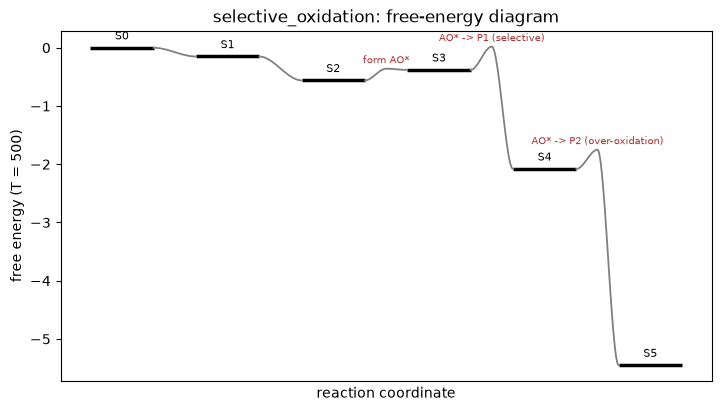

In [2]:
import numpy as np
import discopt_mkm as mk
from discopt_mkm.examples import selective_oxidation
from discopt_mkm.numeric import steady_state_numeric, rate_constants, rates_of_progress, net_rate

m, reactor = selective_oxidation(T=500.0, P_O2=0.5)
A, O2, P1, P2 = (m._by_name[n] for n in ('A','O2','P1','P2'))
T = 500.0
_ = mk.energy_diagram(m)


## Selectivity at one operating point

Solve the steady-state coverages numerically, then form the product rates. Selectivity to `P1` is $S = r_{P_1}/(r_{P_1}+r_{P_2})$.

In [3]:
def solve(P_O2, theta0=None):
    th, fr = steady_state_numeric(m, {A:1.0, O2:P_O2}, T,
                                  theta0=theta0 or {m._by_name['A*']:0.6, m._by_name['O*']:0.3, m._by_name['AO*']:0.01})
    conc = {g: ({A:1.0,O2:P_O2}).get(g,0.0) for g in m.gas_species}
    kf, kr = rate_constants(m, T, th); rops = rates_of_progress(m, kf, kr, th, fr, conc)
    rP1, rP2 = net_rate(m, P1, rops), net_rate(m, P2, rops)
    return th, fr, rP1, rP2

th, fr, rP1, rP2 = solve(0.5)
print(f'at P_O2 = 0.5:  r(P1) = {rP1:.3f},  r(P2) = {rP2:.3f},  S = {rP1/(rP1+rP2):.3f}')
print('coverages:', {a.name: round(float(th[a]),3) for a in m.adsorbates}, 'free =', round(float(fr[m.sites[0]]),3))

at P_O2 = 0.5:  r(P1) = 3.807,  r(P2) = 1.635,  S = 0.700
coverages: {'A*': 0.848, 'O*': 0.085, 'AO*': 0.041} free = 0.027


## The activity/selectivity tradeoff

Sweep the oxygen pressure. More $O_2$ raises the rate (more oxidant) but also raises $\theta_O$, which feeds the over-oxidation branch — so selectivity falls as activity climbs.

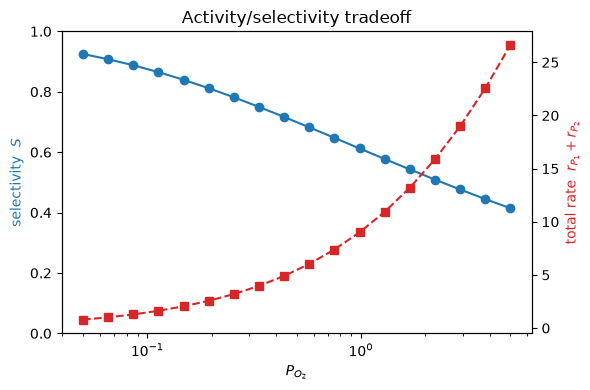

In [4]:
PO2 = np.geomspace(0.05, 5.0, 18)
S, rtot, thO = [], [], []
guess = None
for p in PO2:
    th, fr, rP1, rP2 = solve(p, guess); guess = th
    S.append(rP1/(rP1+rP2)); rtot.append(rP1+rP2); thO.append(float(th[m._by_name['O*']]))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
ax.semilogx(PO2, S, 'o-', color='C0', label='selectivity to P1')
ax.set_xlabel('$P_{O_2}$'); ax.set_ylabel('selectivity  $S$', color='C0'); ax.set_ylim(0,1)
ax2 = ax.twinx(); ax2.semilogx(PO2, rtot, 's--', color='C3', label='total rate')
ax2.set_ylabel('total rate  $r_{P_1}+r_{P_2}$', color='C3')
ax.set_title('Activity/selectivity tradeoff'); fig.tight_layout()


The selectivity-controlling coverage $\theta_O$ rises monotonically with $P_{O_2}$, which is exactly why the over-oxidation branch takes over:

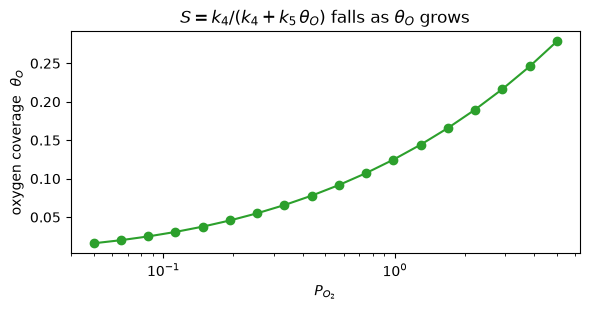

In [5]:
fig, ax = plt.subplots(figsize=(6,3.2))
ax.semilogx(PO2, thO, 'o-', color='C2')
ax.set_xlabel('$P_{O_2}$'); ax.set_ylabel(r'oxygen coverage  $\theta_O$')
ax.set_title(r'$S = k_4/(k_4 + k_5\,\theta_O)$ falls as $\theta_O$ grows'); fig.tight_layout()


## Degree of selectivity control

To *improve* selectivity you need to know which rate constant to move. Define the **degree of selectivity control** of step $i$ as $\;\chi_i = \dfrac{\partial \ln S}{\partial \ln k_i}$, the exact analogue of Campbell's degree of rate control but for the selectivity instead of the rate. `discopt_mkm` computes it by passing the *selectivity expression* to `degree_of_rate_control`, which propagates the steady-state sensitivities analytically through the model.

Because $S$ is homogeneous of degree zero in the rate constants (scaling every $k$ leaves $S$ unchanged), these controls **sum to zero** — a useful consistency check, versus the degree-of-rate controls which sum to one.

In [6]:
from discopt_mkm.analysis import degree_of_rate_control

# near-equilibrium adsorption -> solve in log-coordinates (warm-started) for accurate sensitivities
th, *_ = solve(0.5)
sol = mk.solve_steady_state(m, reactor, coordinates='log', theta0=th,
                            log_box=3.0, reg_weight=0.1, active_tol=1e-13)

drc_P1 = degree_of_rate_control(sol, species=P1)
S_expr = sol.production_rate_expr(P1) / (sol.production_rate_expr(P1) + sol.production_rate_expr(P2))
sel_ctrl = degree_of_rate_control(sol, rate_expr=S_expr)

print(f'degree of RATE control of P1   (sum = {sum(drc_P1.values()):+.3f}):')
for r, v in drc_P1.items():       print(f'   {r.name:28s} {v:+.3f}')
print(f'degree of SELECTIVITY control  (sum = {sum(sel_ctrl.values()):+.3f}):')
for r, v in sel_ctrl.items():     print(f'   {r.name:28s} {v:+.3f}')

degree of RATE control of P1   (sum = +1.000):
   A adsorption                 -0.015
   O2 dissociation              +0.583
   form AO*                     +0.003
   AO* -> P1 (selective)        +0.695
   AO* -> P2 (over-oxidation)   -0.265
degree of SELECTIVITY control  (sum = -0.000):
   A adsorption                 +0.011
   O2 dissociation              -0.181
   form AO*                     +0.001
   AO* -> P1 (selective)        +0.389
   AO* -> P2 (over-oxidation)   -0.221


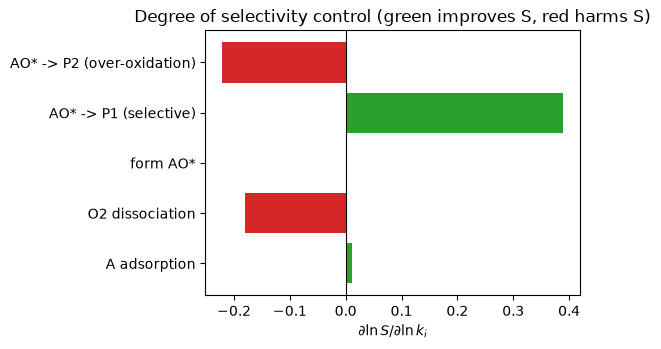

In [7]:
names = [r.name for r in m.reactions]
vals = [sel_ctrl[r] for r in m.reactions]
colors = ['C2' if v > 0 else 'C3' for v in vals]
fig, ax = plt.subplots(figsize=(6,3.6))
ax.barh(names, vals, color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel(r'$\partial \ln S / \partial \ln k_i$')
ax.set_title('Degree of selectivity control (green improves S, red harms S)')
fig.tight_layout()


## Takeaways

- A **branching mechanism** (one intermediate, two product-forming steps) is all you need to model selectivity; `discopt_mkm` assembles the mole balances automatically and `production_rate(P1)` / `production_rate(P2)` give the branch rates.
- The **activity/selectivity tradeoff** is intrinsic here: raising $P_{O_2}$ raises the rate but also $\theta_O$, which feeds the over-oxidation branch $AO^* + O^* \to P_2$.
- The **degree of selectivity control** $\partial \ln S/\partial \ln k_i$ comes from the same automatic-differentiation machinery as the degree of rate control — just analyze the selectivity expression instead of a rate. It points straight at the knobs: accelerate the selective branch ($AO^* \to P_1$), and suppress oxygen supply / the over-oxidation branch. It sums to zero because selectivity is scale-free in the rate constants.
- Adsorption here is near-equilibrium, so the differentiable solve uses **log-coordinates** with a warm start — the same treatment the water-gas-shift DRC example needs.